<a href="https://colab.research.google.com/github/gusjjpv/Caloric-Expenditure-Prediction/blob/main/caloricExpenditurePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap

In [25]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

In [3]:
path = kagglehub.dataset_download("fmendes/fmendesdat263xdemos")
print(os.listdir(path))

100%|██████████| 296k/296k [00:00<00:00, 1.54MB/s]

Extracting files...


['calories.csv', 'exercise.csv']


##Preparar dados



In [5]:
df_exercise = pd.read_csv(os.path.join(path, "exercise.csv"))
df_calories = pd.read_csv(os.path.join(path, "calories.csv"))

df = pd.merge(df_exercise, df_calories, on="User_ID")
display(df.head())

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

X = df.drop(columns=['Calories', 'User_ID'])
y = df['Calories'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
feature_names = ['Idade', 'Altura', 'Peso', 'Duração', 'Batimentos', 'Temp. Corporal', 'Sexo (M=1)']

## Criando modelo


In [7]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # 7 neuronios
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8781.2354 - val_loss: 4177.1113
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1249.8651 - val_loss: 232.6751
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 195.1163 - val_loss: 165.0814
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 152.7138 - val_loss: 135.9873
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 123.1652 - val_loss: 109.0001
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 96.5553 - val_loss: 84.8518
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 73.8201 - val_loss: 65.5262
Epoch 8/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 55.7036 - val_loss: 49.9065
Epoch 9/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 42.0403 - val_loss: 38.1363
Epoch 10/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31.9386 - val_loss: 29.0610
Epoch 11/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24.3924 - val_loss: 22.4380
Epoch 

In [9]:
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(y_pred.shape[0])

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MSE: {mse:.2f}\nR2: {r2:.4f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 0.19
R2: 1.0000
MAE: 0.34
RMSE: 0.44


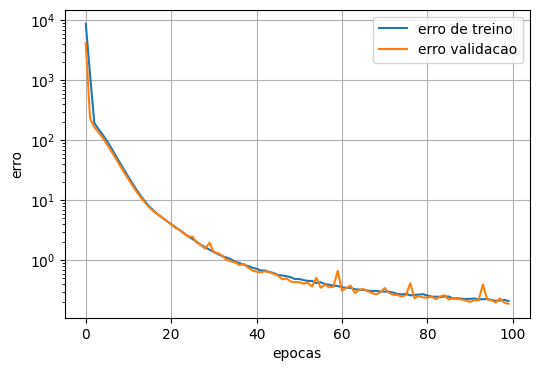

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='erro de treino')
plt.plot(history.history['val_loss'], label='erro validacao')
plt.xlabel('epocas')
plt.ylabel('erro')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
model.save('mlp-128-100-2.keras')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


ia explicavel

In [18]:
explainer = shap.KernelExplainer(model.predict, X_test[:1])
shap_values = explainer.shap_values(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


  0%|          | 0/3000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

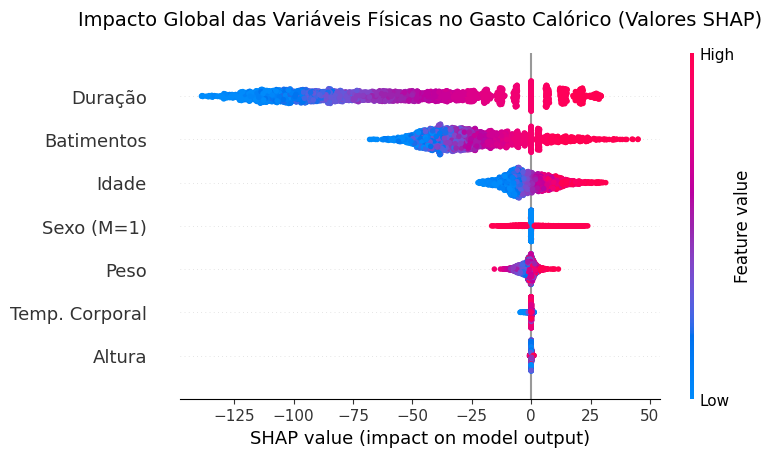

In [26]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if len(shap_values.shape) > 2:
    shap_values = np.squeeze(shap_values)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)

plt.title("Impacto Global das Variáveis Físicas no Gasto Calórico (Valores SHAP)", fontsize=14, pad=20)

plt.show()

In [27]:
display(df.head())

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Gender_male
0,14733363,68,190.0,94.0,29.0,105.0,40.8,231.0,True
1,14861698,20,166.0,60.0,14.0,94.0,40.3,66.0,False
2,11179863,69,179.0,79.0,5.0,88.0,38.7,26.0,True
3,16180408,34,179.0,71.0,13.0,100.0,40.5,71.0,False
4,17771927,27,154.0,58.0,10.0,81.0,39.8,35.0,False
